# Size-dependent fate ablation

**Role:** Analysis.

Plot observed-size bins and fixed-neighborhood cell-count sweeps for every recipient/source pair and hop from 1 to the selected model depth. Choose marker zeroing, trained masking, or context-matched replacement. Load one saved model depth from `training_results/` and evaluate every fold on its own recorded validation organoids. Sampling never uses curvature, predictions or anatomy; the recipient and graph remain unchanged. Models, baseline offsets and target transformations are restored, never refitted. Save case-level effects and support so `ablation_comparison.ipynb` can compare methods on matched source cases.

Zeroing removes one marker bit (all-zero sources are a no-op). Masking hides the whole source fate and requires a positive-rate masking-trained checkpoint. Replacement requires exclusive fates, treats unassigned as an identity, and enumerates alternatives from training-only context matches. A masking-trained model also supports zeroing and replacement for within-checkpoint comparisons.

In [ ]:
from pathlib import Path
import sys
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/models/gnn.py").is_file())  # Locate the repository from the notebook’s working directory.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
ROOT = PROJECT_ROOT  # Repository root used to resolve data and result paths.

## Analysis settings

Choose method, training subfolder, model depth and sampling here. All saved folds are mandatory. Use identical sampling settings across methods; choose a new analysis tag if changing inference settings.

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from src.analysis.interventions.replacement import MatchConfig

# Intervention and saved model selection
ABLATION_TYPE = 'marker_zeroing'  # marker_zeroing, masking, or replacement.
TRAINING_SUBFOLDER = 'gin_depth_training'  # Workflow folder under training_results/; masking uses fate_masking_training.
TRAINING_RUN = None  # Saved run directory name; None requires one available run.
MODEL_DEPTH = 2  # Analyze exact hops 1..depth; depth 0 has no neighbor interactions.
MODEL_NAME = None  # None requires one family; otherwise gin, film, or gin_film_size for masking runs.
HIDDEN_DIM = None  # None requires one saved width at the chosen depth.
MODEL_SEEDS = None  # None includes every saved seed. Every saved fold is always included.
MASKING_RATE = None  # Select a saved rate for ANY analysis of a masking-trained checkpoint, e.g. .05.

# Coverage sampling (restored from 9ae3657: ablation_analysis)
SAMPLING_SCHEME = 'coverage'  # coverage: pair/hop minimum targets; alternatives: uniform or stratified.
CENTER_SAMPLE_SIZE = 2000  # Maximum recipient centers per validation fold; None keeps all (coverage only).
CENTER_MIN_MARKER_COUNT = 50  # Target centers per recipient identity before non-overlap filtering.
CENTER_MIN_PAIR_COUNT = 25  # Target cases per recipient/source identity at EACH hop before filtering.
SAMPLING_SEED = 0  # Original SUBGRAPH_SEED; fold index is added, identical across model seeds/methods.

# Source-cell independence
CENTER_APPLY_NON_OVERLAP = True  # At hop d, retained sources block others within graph distance d.
CENTER_NON_OVERLAP_GROUP_COLUMNS = ('hop', 'center_marker', 'source_marker')  # Apply independently within each pair/hop.

# Alternative sampling schemes
CENTERS_PER_ORGANOID = 5  # Only uniform/stratified: recipients per organoid (per identity for stratified).

# Replacement reference (ignored by other methods)
N_DEPENDENT_REPLACEMENT = False  # False freezes weights at observed N; True recomputes weights at swept N.
MATCHING = MatchConfig(
    neighbors=256,  # Candidate donor cells for local matching.
    max_size_ratio=2.,  # Maximum donor/source count ratio.
    max_degree_ratio=2.,  # Maximum donor/source degree ratio.
    max_composition_l1=1.,  # Maximum neighborhood-composition mismatch.
    min_cells=20,  # Minimum matched donor cells.
    min_organoids=5,  # Minimum donor organoids.
    min_identity_cells=5,  # Minimum cells for each replacement fate.
    min_identity_organoids=3,  # Minimum organoids for each replacement fate.
    max_donors_per_organoid=256,  # Donor quota per training organoid.
)

# Effect scale and uncertainty
GEOMETRIC_NORMALIZATION = False  # Also compute ΔK/(4π/A_ref(N)); A_ref is fitted to training organoids only.
PLOT_METRIC = 'delta_mu'  # delta_mu (curvature), delta_z (transformed), or delta_relative (requires normalization).
BOOTSTRAP_SAMPLES = 500  # Organoid bootstrap resamples for uncertainty intervals.
HEATMAP_DISPLAY_MIN_CASES = 20  # Minimum retained unique cases; int or hop dict, e.g. {1:20,2:30}; also gates size curves.
MIN_PLOT_ORGANOIDS = 1  # Minimum organoid support per displayed pair.

# Execution and output
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # Inference device.
BATCH_SIZE = 128  # Maximum edited subgraphs per prediction batch.
RUN_INFERENCE = True  # False reloads this exact completed analysis without inference.
ANALYSIS_TAG = 'default'  # Output label; changed inference settings automatically select a separate version.

# Size dependence
SWEEP_COUNTS = [80,150,300,550,700]  # Supplied N values; graphs and sampled cells remain fixed.
SIZE_BINS = [0,150,250,350,500,800,np.inf]  # Bins for effects at observed organoid sizes.


## Restore the selected model family

Check the catalog before inference. Fold-specific validation inputs, global scaling and target transforms come from the selected saved run.

In [ ]:
NOTEBOOK_NAME = 'size_dependent_ablation'
VIEW = 'size'
from dataclasses import asdict
from src.artifacts.paths import resolve_training_run
from src.artifacts.runs import AnalysisRun, select_depth_records
from src.artifacts.provenance import workflow_fingerprint, analysis_output_path
from src.analysis.interventions.masking import checked_settings
from src.analysis.interventions.fate_edits import (
    METHODS, fate_graphs, sample_fate_contexts, build_replacement_reference,
    replacement_distribution, evaluate_fate_edit, add_geometric_scale,
    summarize_fate_effects, load_ablation_result,
)
if ABLATION_TYPE not in METHODS or MODEL_DEPTH < 1:
    raise ValueError('Choose marker_zeroing, masking, or replacement and a depth >= 1.')
if Path(ANALYSIS_TAG).name != ANALYSIS_TAG or ANALYSIS_TAG in ('.','..',''):
    raise ValueError('ANALYSIS_TAG must be a simple folder name.')
if PLOT_METRIC == 'delta_relative' and not GEOMETRIC_NORMALIZATION:
    raise ValueError('Enable geometric normalization to plot delta_relative.')
RUN_DIR = resolve_training_run(ROOT, TRAINING_SUBFOLDER, TRAINING_RUN)
run = AnalysisRun(RUN_DIR,root=ROOT)
records = select_depth_records(run, MODEL_DEPTH, model_name=MODEL_NAME,
    hidden_dim=HIDDEN_DIM, seeds=MODEL_SEEDS, rate=MASKING_RATE)
if ABLATION_TYPE == 'masking' and (run.modern or not run.legacy.masking or MASKING_RATE is None or MASKING_RATE <= 0):
    raise ValueError('Masking requires a positive-rate checkpoint from fate_masking_training.')
display(records)
HOPS = tuple(range(1, MODEL_DEPTH + 1))
width = int(records.iloc[0].hidden_dim) if 'hidden_dim' in records else int(run.legacy.settings['HIDDEN_DIM'])
variant = f'{records.iloc[0]["name"]}_d{MODEL_DEPTH}_h{width}_{ABLATION_TYPE}'
if MASKING_RATE is not None:
    variant += f'_p{MASKING_RATE:g}'
if ABLATION_TYPE == 'replacement':
    variant += '_Ndependent' if N_DEPENDENT_REPLACEMENT else '_fixed'
OUTPUT_BASE_DIR = RUN_DIR/'analysis'/NOTEBOOK_NAME/variant/ANALYSIS_TAG


## Sample and evaluate held-out neighborhoods

The same physical sources are reused across model seeds and supplied counts. Exact graph distances exclude the recipient (hop 0). Replacement donors are restricted to outer-training organoids and never matched on curvature or anatomical labels. Shards can be resumed only with matching settings and code.

Coverage sampling uses the original greedy minimum-coverage and rare-feature fill algorithm from commit `9ae3657`. It considers all validation centers, chooses the first positive source in each exact ring as in the original single-source ablation, and targets every recipient/source/hop combination. Unassigned is included as an extra identity for sampling only. The budget and targets apply separately to each fold. Non-overlap is imposed once on physical sources, separately per marker pair and hop, and reused at every N. Targets are best-effort; no curvature-dependent filtering or filling is performed. Saved coverage tables distinguish available, selected, and retained cases.


The output label is reused only when saved inference settings and code match. Otherwise a deterministic settings/code suffix selects a separate folder, preserving earlier results. Repeating the same configuration resumes its own completed checkpoint shards. The resolved output directory is printed below and can be copied into the comparison notebook.


In [ ]:
# The loop is deliberately visible: restore, sample, build training donors, then edit.
counts = list(SWEEP_COUNTS) if VIEW == 'size' else []
if len(set(counts)) != len(counts) or any(not np.isfinite(n) or n<=0 for n in counts):
    raise ValueError('Sweep counts must be distinct, positive and finite.')
if VIEW == 'size' and not counts:
    raise ValueError('Supply at least one N for the size sweep.')
config = dict(training_run=str(RUN_DIR.resolve()), model_keys=records.key.tolist(), method=ABLATION_TYPE,
    depth=MODEL_DEPTH, sampling_scheme=SAMPLING_SCHEME, centers=CENTERS_PER_ORGANOID, sampling_seed=SAMPLING_SEED,
    center_sample_size=CENTER_SAMPLE_SIZE, center_min_marker_count=CENTER_MIN_MARKER_COUNT,
    center_min_pair_count=CENTER_MIN_PAIR_COUNT, center_apply_non_overlap=CENTER_APPLY_NON_OVERLAP,
    center_non_overlap_group_columns=list(CENTER_NON_OVERLAP_GROUP_COLUMNS),
    n_dependent_replacement=N_DEPENDENT_REPLACEMENT, matching=asdict(MATCHING), counts=counts,
    geometric_normalization=GEOMETRIC_NORMALIZATION, view=VIEW,
    code_sha256=workflow_fingerprint(PROJECT_ROOT/'experiments/ablation'/f'{NOTEBOOK_NAME}.ipynb'))
OUTPUT_DIR = analysis_output_path(OUTPUT_BASE_DIR,config)
if OUTPUT_DIR != OUTPUT_BASE_DIR:
    print('Earlier results preserved at:',OUTPUT_BASE_DIR)
    print('Current settings/code use a separate result version.')
print('Results:',OUTPUT_DIR)
if RUN_INFERENCE:
    OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
    checked_settings(OUTPUT_DIR/'settings.json',config)
    (OUTPUT_DIR/'cases').mkdir(exist_ok=True)
    (OUTPUT_DIR/'support').mkdir(exist_ok=True)
    for record in records.itertuples():
        path = OUTPUT_DIR/'cases'/f'{record.key}.csv.gz'
        if path.exists():
            print('Reuse completed checkpoint analysis:',record.key)
            continue
        selection = run.select(record.key,device=DEVICE)
        fold_seed = SAMPLING_SEED + int(record.fold)
        subgraphs,manifest,sampling_info = sample_fate_contexts(fate_graphs(selection),selection['marker_names'],MODEL_DEPTH,
            scheme=SAMPLING_SCHEME,centers=CENTERS_PER_ORGANOID,seed=fold_seed,
            max_subgraphs=CENTER_SAMPLE_SIZE,min_center_count=CENTER_MIN_MARKER_COUNT,
            min_pair_count=CENTER_MIN_PAIR_COUNT,apply_non_overlap=CENTER_APPLY_NON_OVERLAP,
            non_overlap_group_columns=CENTER_NON_OVERLAP_GROUP_COLUMNS,return_info=True)
        for table_name in ('center_coverage','pair_coverage','case_non_overlap'):
            sampling_info[table_name].to_csv(OUTPUT_DIR/'support'/f'{record.key}_{table_name}.csv.gz',index=False)
        print(f"Sampling {record.key}: {sampling_info['n_selected']} recipient centers before case filtering")
        display(sampling_info['pair_coverage'])
        if manifest.empty:
            raise ValueError(f'No eligible neighboring source cells for {record.key}.')
        marker_names = selection['marker_names']
        observed_weights = None
        if ABLATION_TYPE == 'replacement':
            matcher,contexts = build_replacement_reference(selection,manifest,MODEL_DEPTH,config=MATCHING,seed=fold_seed)
            observed_weights,donor_audit = replacement_distribution(manifest,contexts,matcher,marker_names)
            donor_audit.to_csv(OUTPUT_DIR/'support'/f'{record.key}_observed.csv.gz',index=False)
        pieces = []
        for count in [None,*counts]:
            weights = observed_weights
            if ABLATION_TYPE == 'replacement' and count is not None and N_DEPENDENT_REPLACEMENT:
                weights,donor_audit = replacement_distribution(manifest,contexts,matcher,marker_names,count=count)
                donor_audit.to_csv(OUTPUT_DIR/'support'/f'{record.key}_N{count:g}.csv.gz',index=False)
            frame = evaluate_fate_edit(selection,subgraphs,manifest,ABLATION_TYPE,count=count,weights=weights,
                device=DEVICE,batch_size=BATCH_SIZE)
            frame['fold'],frame['seed'],frame['model_key'] = record.fold,record.seed,record.key
            if GEOMETRIC_NORMALIZATION:
                frame,area_reference = add_geometric_scale(frame,selection)
                (OUTPUT_DIR/'support'/f'{record.key}_area_reference.json').write_text(json.dumps(area_reference,indent=2))
            pieces.append(frame)
        saved = pd.concat(pieces,ignore_index=True)
        saved['center_marker_names'] = saved.center_marker_names.map(json.dumps)
        temporary = path.with_suffix('.tmp')
        saved.to_csv(temporary,index=False,compression='gzip')
        temporary.replace(path)
        membership = {role:[g.organoid_str for g in selection['groups'][role]] for role in ('train','val')}
        (OUTPUT_DIR/'support'/f'{record.key}_membership.json').write_text(json.dumps(membership,indent=2))
        print(f'{record.key}: {len(manifest)} fixed source cases, {len(counts)} supplied counts')
        del selection,subgraphs
    (OUTPUT_DIR/'complete.json').write_text(json.dumps({'checkpoints':len(records)}))
cases,saved_config = load_ablation_result(OUTPUT_DIR)
if saved_config != config:
    raise ValueError('Saved settings differ; use their original settings or a new ANALYSIS_TAG.')
display(cases.groupby(['analysis','hop']).agg(cases=('case_id','size'),
    organoids=('organoid_str','nunique'),supported_fraction=('supported','mean')))

sampling_pairs = pd.concat([pd.read_csv(OUTPUT_DIR/'support'/f'{key}_pair_coverage.csv.gz').assign(model_key=key)
    for key in records.key],ignore_index=True)
PLOT_IDENTITIES = list(sampling_pairs.center_marker.unique())


## Sample-count heatmaps

Show separate count figures for observed and sweep cohorts. Observed counts pool the configured size bins; counts for each individual bin remain in `size_summary.csv`. Sweep counts describe the fixed cohort supported across all supplied N values: a case evaluated at nine N values is counted once, not nine times.
Rows are center identities and columns are perturbation/source identities. Each hop has its own panel. Blue intensity uses a shared logarithmic count scale, and every cell contains its integer sample count (including zero). Counts are after non-overlap and replacement-support filtering; low-support pairs remain visible here even when their effect cells are hatched. Repeated model seeds do not create additional samples.


Count figures from saved inference: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/gin_depth_training/scMultiplexpaper_20260918_161107/analysis/size_dependent_ablation/gin_d2_h128_marker_zeroing/default_4640a535cbfe


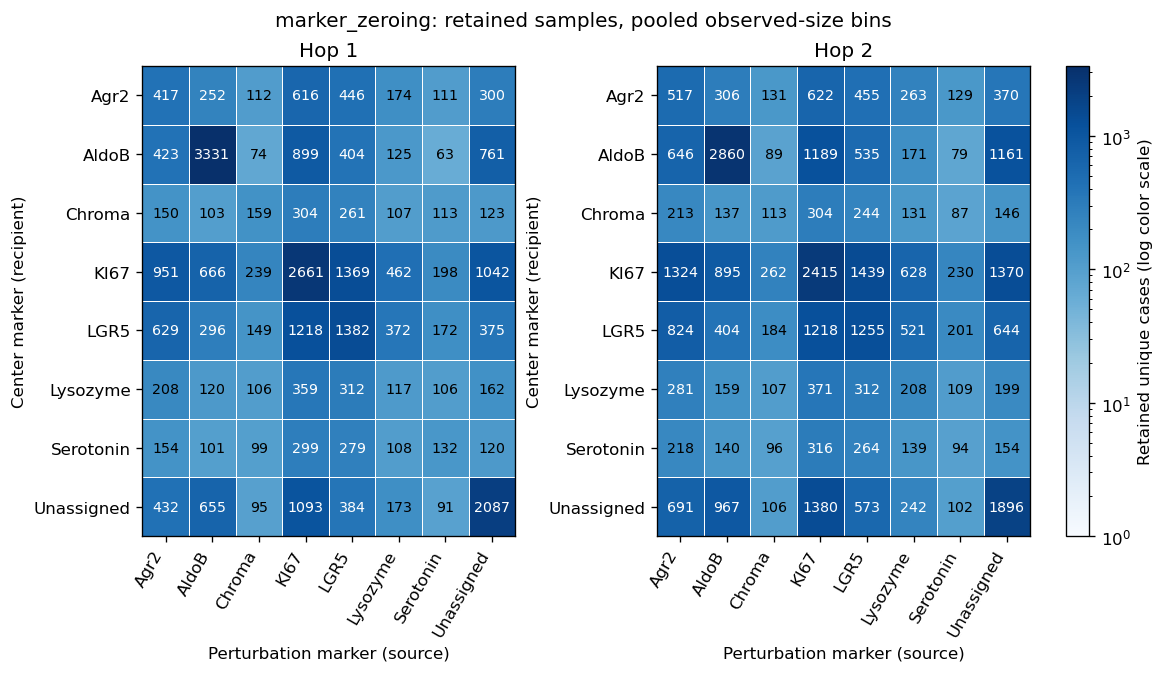

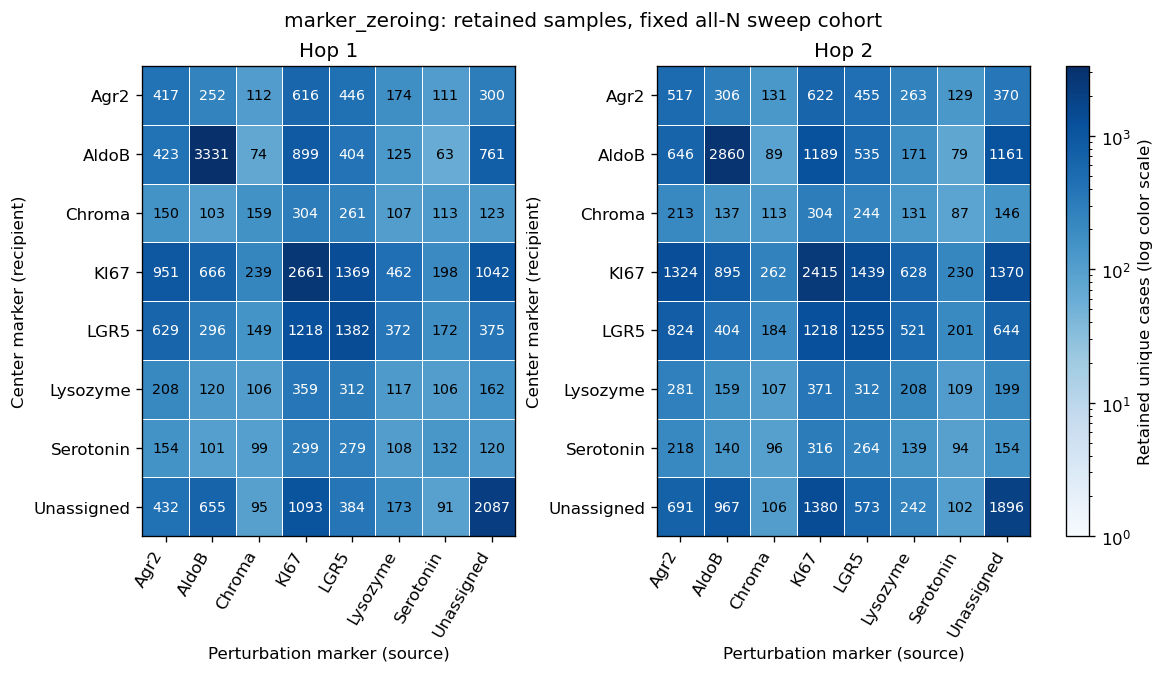

In [ ]:
from src.analysis.interventions.fate_edits import count_fate_cases
from src.plotting.influence_maps import plot_pair_count_heatmaps
pair_counts = count_fate_cases(cases,metric=PLOT_METRIC,size_bins=SIZE_BINS)
pair_counts.to_csv(OUTPUT_DIR/'pair_sample_counts.csv',index=False)
count_limit = max(2,float(pair_counts.n_cases.max())) if not pair_counts.empty else 2
for mode,description in [('observed','pooled observed-size bins'),('sweep','fixed all-N sweep cohort')]:
    fig = plot_pair_count_heatmaps(pair_counts[pair_counts.analysis==mode],hops=HOPS,
        marker_names=PLOT_IDENTITIES,vmax=count_limit,title=f'{ABLATION_TYPE}: retained samples, {description}')
    fig.savefig(OUTPUT_DIR/f'pair_sample_counts_{mode}.png',dpi=160,bbox_inches='tight')
    plt.show()


## Summarize and plot

Average cases and seeds within organoids, then weight organoids equally. Bands/tables give pointwise organoid-bootstrap intervals conditional on trained models. Cells below HEATMAP_DISPLAY_MIN_CASES retained cases are white and hatched in heatmaps; size curves have gaps at insufficiently supported bins. The default is the original 20-case threshold; a per-hop dictionary is also supported. Counts refer to unique physical recipient/source cases after non-overlap and donor support, not repeated model seeds or sweep points. MIN_PLOT_ORGANOIDS is an additional independent threshold. The summary exports these counts as n_cases. For sweeps, retain only source cases supported at every supplied N; report support before interpreting their curves. Positive effects mean edited minus intact prediction is positive. These are predictor contrasts, not causal cell interactions.

Observed and sweep curves use distinct colors, with matching uncertainty bands. Observed curves also use solid lines and circles; sweeps use dashed lines and squares. Each figure title identifies the exact hop distance.


In [ ]:
(OUTPUT_DIR/'plot_settings.json').write_text(json.dumps(dict(
    metric=PLOT_METRIC,heatmap_display_min_cases=HEATMAP_DISPLAY_MIN_CASES,
    min_plot_organoids=MIN_PLOT_ORGANOIDS,bootstrap_samples=BOOTSTRAP_SAMPLES),indent=2))
summary = summarize_fate_effects(cases,view='size',metric=PLOT_METRIC,size_bins=SIZE_BINS,
    draws=BOOTSTRAP_SAMPLES,seed=SAMPLING_SEED)
summary.to_csv(OUTPUT_DIR/'size_summary.csv',index=False)
display(summary)
from src.plotting.influence_maps import plot_pair_size_curves
for hop in HOPS:
    if summary.empty or hop not in summary.hop.values:
        print(f'No supported effects at hop {hop}.')
        continue
    fig = plot_pair_size_curves(summary,hop=hop,min_organoids=MIN_PLOT_ORGANOIDS,min_cases=HEATMAP_DISPLAY_MIN_CASES,
        title=f'{ABLATION_TYPE}: hop {hop}, {PLOT_METRIC}')
    fig.savefig(OUTPUT_DIR/f'hop{hop}_{PLOT_METRIC}.png',dpi=160,bbox_inches='tight')
    plt.show()
